In [6]:
import pandas as pd
import numpy as np

In [7]:
!pip install pyxlsb

In [8]:
df = pd.read_excel(r'/content/emissions_by_unit_and_fuel_type_c_d_aa.xlsb', sheet_name="UNIT_DATA")

In [9]:
df.head()

,This file contains data collected by the Greenhouse Gas Reporting Program for 2011-2023,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,This data was reported to EPA by facilities as...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All emissions data is presented in units of me...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,** A file containing matches between each GHGR...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,** Additional information on facility location...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"*** Explanation about what an ""Electricity Gen...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.tail()

,This file contains data collected by the Greenhouse Gas Reporting Program for 2011-2023,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
268779,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2015,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,33757.8,16,19.072,0
268780,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2014,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,32901.2,15.5,18.476,0
268781,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2013,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,42700.7,20.25,24.138,0
268782,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2012,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,46840.7,22,26.224,0
268783,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2011,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,53482.2,25.25,30.098,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268784 entries, 0 to 268783
Data columns (total 17 columns):
 #   Column                                                                                   Non-Null Count   Dtype 
---  ------                                                                                   --------------   ----- 
 0   This file contains data collected by the Greenhouse Gas Reporting Program for 2011-2023  268784 non-null  object
 1   Unnamed: 1                                                                               239089 non-null  object
 2   Unnamed: 2                                                                               268779 non-null  object
 3   Unnamed: 3                                                                               268779 non-null  object
 4   Unnamed: 4                                                                               268779 non-null  object
 5   Unnamed: 5                                                

In [12]:
df.drop(index=df.index[:5], inplace=True)

# Set the first row as header
df.columns = df.iloc[0]

# Drop the row that became the header
df = df.iloc[1:].reset_index(drop=True)


We removed the first 5 rows and set the next one as a header and then we removed the row that became the header from the data

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268778 entries, 190923 to 130516
Data columns (total 26 columns):
 #   Column                                                        Non-Null Count   Dtype  
---  ------                                                        --------------   -----  
 0   Facility Id                                                   268778 non-null  int64  
 1   Facility Name                                                 268778 non-null  object 
 2   City                                                          268778 non-null  object 
 3   State                                                         268778 non-null  object 
 4   Primary NAICS Code                                            268778 non-null  object 
 5   Reporting Year                                                268778 non-null  int64  
 6   Industry Type (subparts)                                      268778 non-null  object 
 7   Industry Type (sectors)                                 

In [13]:
df.head()

5,Facility Id,FRS Id,Facility Name,City,State,Primary NAICS Code,Reporting Year,Industry Type (subparts),Industry Type (sectors),Unit Name,Unit Type,Unit Reporting Method,Unit Maximum Rated Heat Input Capacity (mmBTU/hr),Unit CO2 emissions (non-biogenic),Unit Methane (CH4) emissions,Unit Nitrous Oxide (N2O) emissions,Unit Biogenic CO2 emissions (metric tons)
0,1001155,110000397516,1500 South Tibbs LLC d/b/a Aurorium Indianapol...,Indianapolis,IN,325199,2023,C,Chemicals,GP-1,NaN,Tier1/2/3,91.8,64740.5,30.5,36.356,0
1,1012147,NaN,17Z Gas Plant - Chevron USA Inc.,McKittrick,CA,211130,2018,"C,NN,W","Natural Gas and Natural Gas Liquids Suppliers,...",CP-03.00,OCS (Other combustion source),Tier1/2/3,30,3304.7,1.5,1.788,0
2,1012147,NaN,17Z Gas Plant - Chevron USA Inc.,McKittrick,CA,211130,2018,"C,NN,W","Natural Gas and Natural Gas Liquids Suppliers,...",CP-03.01,OCS (Other combustion source),Tier1/2/3,30,0.2,0,0,0
3,1012147,NaN,17Z Gas Plant - Chevron USA Inc.,McKittrick,CA,211130,2018,"C,NN,W","Natural Gas and Natural Gas Liquids Suppliers,...",CP-03.02,OCS (Other combustion source),Tier1/2/3,30,175,0,0,0
4,1012147,NaN,17Z Gas Plant - Chevron USA Inc.,McKittrick,CA,211130,2017,"C,NN,W","Natural Gas and Natural Gas Liquids Suppliers,...",CP-03.00,OCS (Other combustion source),Tier1/2/3,30,9106.1,4.25,5.066,0


In [14]:
df.tail()

5,Facility Id,FRS Id,Facility Name,City,State,Primary NAICS Code,Reporting Year,Industry Type (subparts),Industry Type (sectors),Unit Name,Unit Type,Unit Reporting Method,Unit Maximum Rated Heat Input Capacity (mmBTU/hr),Unit CO2 emissions (non-biogenic),Unit Methane (CH4) emissions,Unit Nitrous Oxide (N2O) emissions,Unit Biogenic CO2 emissions (metric tons)
268773,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2015,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,33757.8,16,19.072,0
268774,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2014,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,32901.2,15.5,18.476,0
268775,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2013,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,42700.7,20.25,24.138,0
268776,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2012,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,46840.7,22,26.224,0
268777,1003318,110043796675,ZYBACH CRYOGENIC PLANT,Briscoe,TX,211111,2011,"C,W",Petroleum and Natural Gas Systems,GP-Zybach,OCS (Other combustion source),Tier1/2/3,32,53482.2,25.25,30.098,0


In [15]:
df.isnull().sum()

,0
5,
Facility Id,0
FRS Id,29690
Facility Name,0
City,0
State,0
Primary NAICS Code,16
Reporting Year,0
Industry Type (subparts),0
Industry Type (sectors),0


In [73]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.replace(['NaN', 'nan', 'None'], np.nan, inplace=True)

/tmp/ipython-input-3553819837.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(['NaN', 'nan', 'None'], np.nan, inplace=True)


In [17]:
df.isnull().sum()

,0
5,
Facility Id,0
FRS Id,29690
Facility Name,0
City,0
State,0
Primary NAICS Code,16
Reporting Year,0
Industry Type (subparts),0
Industry Type (sectors),0


In [19]:
df.drop("FRS Id", axis=1, inplace=True)

So this column was dropped because it has null values and this column is a unique identfiyer for that we have facility ID so we have no use for this column

In [21]:
df[df["Primary NAICS Code"].isna()]

5,Facility Id,Facility Name,City,State,Primary NAICS Code,Reporting Year,Industry Type (subparts),Industry Type (sectors),Unit Name,Unit Type,Unit Reporting Method,Unit Maximum Rated Heat Input Capacity (mmBTU/hr),Unit CO2 emissions (non-biogenic),Unit Methane (CH4) emissions,Unit Nitrous Oxide (N2O) emissions,Unit Biogenic CO2 emissions (metric tons)
14191,1013060,Arcosa Lightweight Indiana,Mooresville,IN,NaN,2022,C,Other,GP-Kilns,OCS (Other combustion source),Tier1/2/3,100.00,51520.8,24.50,29.204,0.0
25848,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",GP-1,OCS (Other combustion source),Tier1/2/3,1.35,74.3,0.00,0.298,0.0
25849,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",GP-2,OCS (Other combustion source),Tier1/2/3,4.00,4776.0,2.25,2.682,0.0
25850,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",Lime Kiln No.4,Pulp Mill Lime Kiln,NaN,NaN,13545.6,15.75,0.298,NaN
25851,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",Lime Kiln No.5,Pulp Mill Lime Kiln,NaN,NaN,25324.0,28.75,0.298,NaN
25852,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",PB - No. 1 Natural Gas Package Boiler,"OB (Boiler, other)",Tier1/2/3,225.00,71903.0,34.00,40.528,0.0
25853,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",PB - No. 2 Natural Gas Package Boiler,"OB (Boiler, other)",Tier1/2/3,225.00,72645.8,34.25,40.826,0.0
25854,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",PB - No. 4,"PCT (Pulverized coal, tangentially-fired)",Tier1/2/3,535.00,347831.7,907.50,1571.056,0.0
25855,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",PB - Riley Bark,S (Stoker Boiler),Tier1/2/3,380.00,106365.4,420.50,1335.040,74739.8
25856,1000230,Blue Ridge Paper Products LLC,CANTON,NC,NaN,2022,"AA,C,TT","Pulp and Paper, Waste",PB - Riley Coal,"PCWD (Pulverized coal, wall-fired, dry bottom)",Tier1/2/3,399.00,189537.1,467.00,804.898,0.0


So here we tried to identify the 16 null values then by identfiying them we were planing to impute their nacis code manually from gov't website but we couldn't find the NAICS code for the companies here

In [22]:
df['Primary NAICS Code'] = df['Primary NAICS Code'].fillna('Unknown')

So here I substituted it with "Unknown" because deep learning models use embeddings, and embeddings require every categorical value to be a valid string. This method also identifies unknown categories, so rather than dropping them, imputing is better. You might be wondering why impute an integer with a string — the answer is that even though NAICS codes contain digits, they are labels, not numbers. NAICS codes behave like ZIP codes, phone area codes, or product category IDs; therefore, they are categorical.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268778 entries, 0 to 268777
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Facility Id                                        268778 non-null  int64  
 1   Facility Name                                      268778 non-null  object 
 2   City                                               268778 non-null  object 
 3   State                                              268778 non-null  object 
 4   Primary NAICS Code                                 268778 non-null  object 
 5   Reporting Year                                     268778 non-null  int64  
 6   Industry Type (subparts)                           268778 non-null  object 
 7   Industry Type (sectors)                            268778 non-null  object 
 8   Unit Name                                          268778 non-null  object

In [25]:
df[df["Unit Biogenic CO2 emissions (metric tons)"].isna()]

5,Facility Id,Facility Name,City,State,Primary NAICS Code,Reporting Year,Industry Type (subparts),Industry Type (sectors),Unit Name,Unit Type,Unit Reporting Method,Unit Maximum Rated Heat Input Capacity (mmBTU/hr),Unit CO2 emissions (non-biogenic),Unit Methane (CH4) emissions,Unit Nitrous Oxide (N2O) emissions,Unit Biogenic CO2 emissions (metric tons)
3938,1007273,Ahlstrom - Munksjo Mosinee LLC,MOSINEE,WI,322121,2017,"AA,C,TT","Pulp and Paper, Waste",#14 Recovery Boiler (B21),Chemical Recovery Furnace,NaN,NaN,5598.6,63.00,162.708,NaN
3939,1007273,Ahlstrom - Munksjo Mosinee LLC,MOSINEE,WI,322121,2017,"AA,C,TT","Pulp and Paper, Waste",Lime Kiln (P36),Pulp Mill Lime Kiln,NaN,NaN,11962.5,15.25,0.000,NaN
3940,1007273,Ahlstrom - Munksjo Mosinee LLC,MOSINEE,WI,322121,2016,"AA,C,TT","Pulp and Paper, Waste",#14 Recovery Boiler (B21),Chemical Recovery Furnace,NaN,NaN,6999.2,61.50,157.940,NaN
3941,1007273,Ahlstrom - Munksjo Mosinee LLC,MOSINEE,WI,322121,2016,"AA,C,TT","Pulp and Paper, Waste",Lime Kiln (P36),Pulp Mill Lime Kiln,NaN,NaN,10891.7,13.75,0.000,NaN
3942,1007273,Ahlstrom - Munksjo Mosinee LLC,MOSINEE,WI,322121,2015,"AA,C,TT","Pulp and Paper, Waste",#14 Recovery Boiler (B21),Chemical Recovery Furnace,NaN,NaN,5131.2,68.50,177.906,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266543,1001889,WOODLAND PULP LLC,BAILEYVILLE,ME,322110,2012,"AA,C,MM,TT","Petroleum Product Suppliers, Pulp and Paper, W...",Unit 15,Pulp Mill Lime Kiln,NaN,NaN,34145.3,43.50,0.000,NaN
266546,1001889,WOODLAND PULP LLC,BAILEYVILLE,ME,322110,2011,"AA,C,MM,TT","Petroleum Product Suppliers, Pulp and Paper, W...",Unit 02,Chemical Recovery Furnace,NaN,NaN,23126.6,6111.25,12147.076,NaN
266547,1001889,WOODLAND PULP LLC,BAILEYVILLE,ME,322110,2011,"AA,C,MM,TT","Petroleum Product Suppliers, Pulp and Paper, W...",Unit 15,Pulp Mill Lime Kiln,NaN,NaN,44153.3,49.75,0.000,NaN
266548,1001889,WOODLAND PULP LLC,BAILEYVILLE,ME,322110,2010,"AA,C",Pulp and Paper,Unit 02,Chemical Recovery Furnace,NaN,NaN,16876.1,5698.50,11327.278,NaN


In [26]:
df['Unit Biogenic CO2 emissions (metric tons)'].fillna(0, inplace=True)

/tmp/ipython-input-1745492239.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Unit Biogenic CO2 emissions (metric tons)'].fillna(0, inplace=True)


So Here we imputed Unit Biogenic CO2 emissions (metric tons) with 0 because in most factories this value is either unknown or 0 so rather than removing it repalcing the null values with 0 is the more desirable aproach

In [28]:
col = 'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)'

df[col] = df.groupby('Unit Type')[col].transform(
    lambda x: x.fillna(x.median())
)


So here we imputed the missing values by using the median within each Unit Type rather than the global median. This is because heat input capacity is strongly determined by unit type. So we first grouped the data by unit type and used .transform this applies a function to each group type but returns a result aligned to the original DataFrame index, so we can directly assign it back to the column. Thenwe calcualted the median Heat Input Capacity for each unit type and filled each missing values with the median of its corresponding Unit Type catagory.

In [30]:
df['Unit Type'] = df['Unit Type'].fillna('Unknown')

So here we we imputed it with unknown because rather than removing it deep learning models use embeddings and having an Unknown category is natural.

In [31]:
col = 'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)'

global_median = df[col].median()
df[col] = df[col].fillna(global_median)



Here we impute using global median. This is safe because these units already have Unit Type Unknown and we dont know their unit type so using the global mean is more practical.

In [33]:
# drop the column correctly using the 'columns' parameter
df.drop(columns=['Unit Reporting Method'], inplace=True)

I dropped this column because of its lack of Predictive Power, the reporting method (e.g., Tier 1, Tier 3) describes how the emissions data was measured or estimated for regulatory compliance and it does not describe why the emission level is high or low.

In [34]:
# normalize column names to remove accidental leading/trailing whitespace
df.columns = df.columns.str.strip()

# calculate CO2-equivalent (GWP: CH4=25, N2O=298)
df['Total_CO2e'] = (
    df['Unit CO2 emissions (non-biogenic)']
    + df['Unit Biogenic CO2 emissions (metric tons)']
    + df['Unit Methane (CH4) emissions'] * 25
    + df['Unit Nitrous Oxide (N2O) emissions'] * 298
)

Here we created this new feature because the green house gases dosent have the same effect. So 1 unit of metahne has the effect of 25 CO2 and one unit of Nitrous Oxide has the effect of 298 CO2. The other thing is it will gving our model one clear target to predict.


--- Outlier Detection Report ---

Total_CO2e
  Q1: 215.60
  Q3: 63190.67
  IQR: 62975.07
  Lower Bound: -94247.00
  Upper Bound: 157653.27
  Min Value: 0.00
  Max Value: 45538010.37
  Outliers: 41837

Unit Maximum Rated Heat Input Capacity (mmBTU/hr)
  Q1: 8.00
  Q3: 91.40
  IQR: 83.40
  Lower Bound: -117.10
  Upper Bound: 216.50
  Min Value: 0.00
  Max Value: 147000000.00
  Outliers: 33827


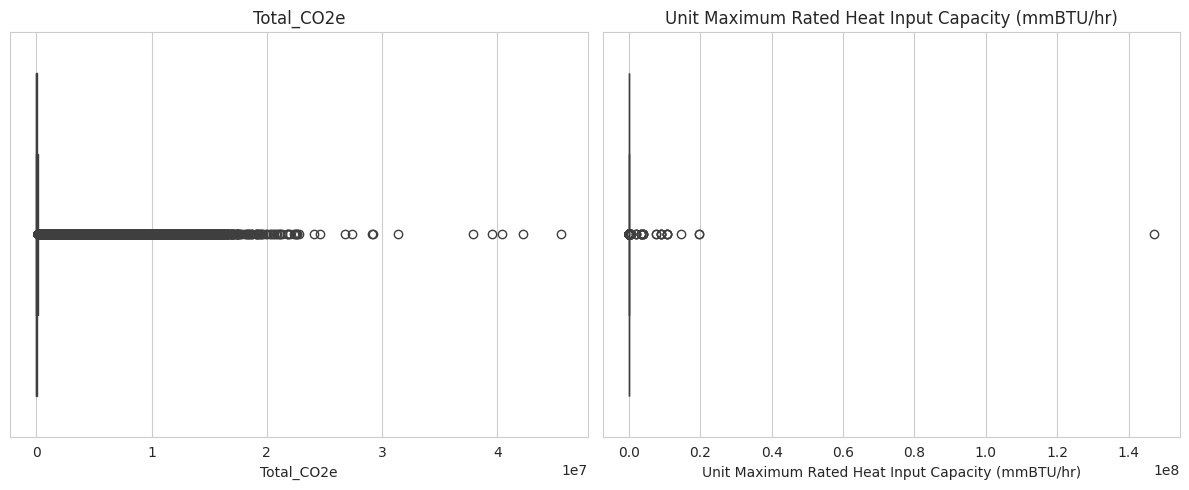

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['Total_CO2e', 'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)']
results = {}

plt.figure(figsize=(12, 5))

for i, col in enumerate(features):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    UB = Q3 + 1.5 * IQR


    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    results[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': LB,
        'Upper_Bound': UB,
        'Min_Value': df[col].min(),
        'Max_Value': df[col].max(),
        'Outliers_Count': (df[col] > UB).sum()
    }

    plt.subplot(1, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.savefig('Outlier_Detection_Boxplots.png')

print("\n--- Outlier Detection Report ---")
for col, r in results.items():
    print(f"\n{col}")
    print(f"  Q1: {r['Q1']:.2f}")
    print(f"  Q3: {r['Q3']:.2f}")
    print(f"  IQR: {r['IQR']:.2f}")
    print(f"  Lower Bound: {r['Lower_Bound']:.2f}")
    print(f"  Upper Bound: {r['Upper_Bound']:.2f}")
    print(f"  Min Value: {r['Min_Value']:.2f}")
    print(f"  Max Value: {r['Max_Value']:.2f}")
    print(f"  Outliers: {r['Outliers_Count']}")


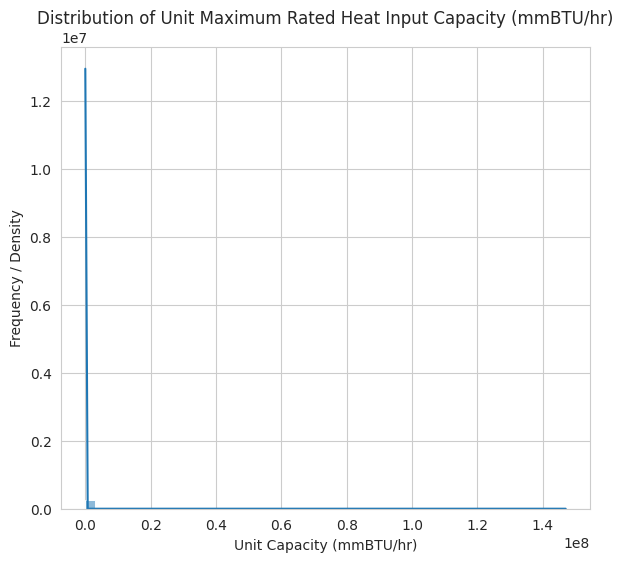

In [37]:

column_name = col
data_series = df[column_name]

plt.figure(figsize=(15, 6))

# --- Subplot 1: Histogram and Kernel Density Estimate (KDE) ---
plt.subplot(1, 2, 1)
sns.histplot(data_series.dropna(), kde=True, bins=50)
plt.title(f'Distribution of {column_name}')
plt.xlabel('Unit Capacity (mmBTU/hr)')
plt.ylabel('Frequency / Density')

plt.show()

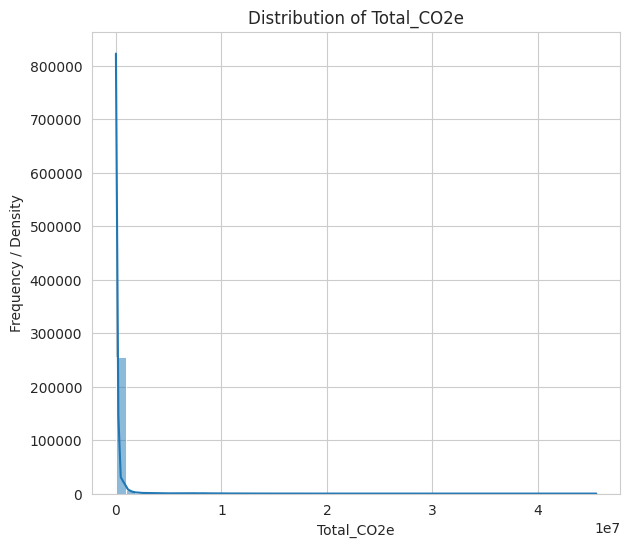

In [38]:

column_name = "Total_CO2e"
data_series = df[column_name]

plt.figure(figsize=(15, 6))

# --- Subplot 1: Histogram and Kernel Density Estimate (KDE) ---
plt.subplot(1, 2, 1)
sns.histplot(data_series.dropna(), kde=True, bins=50)
plt.title(f'Distribution of {column_name}')
plt.xlabel('Total_CO2e')
plt.ylabel('Frequency / Density')

plt.show()

In [39]:
total_count = len(df)
zero_count = (df['Total_CO2e'] == 0).sum()

print(f"Total records: {total_count}")
print(f"Zero-emission records: {zero_count}")
print(f"Percent zeros: {100 * zero_count / total_count:.2f}%")

Total records: 268778
Zero-emission records: 9827
Percent zeros: 3.66%


In [40]:
total_count = len(df)
zero_count = (df['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)'] == 0).sum()

print(f"Total records: {total_count}")
print(f"Unit Maximum Rated Heat Input Capacity (mmBTU/hr) zeros: {zero_count}")
print(f"Percent zeros: {100 * zero_count / total_count:.2f}%")

Total records: 268778
Unit Maximum Rated Heat Input Capacity (mmBTU/hr) zeros: 956
Percent zeros: 0.36%


In [41]:
neg_count = (df['Total_CO2e'] < 0).sum()

print(f"Negative Total_CO2e values: {neg_count}")

Negative Total_CO2e values: 0


In [42]:
# ============================================================
# YEO–JOHNSON FOR CO2e
# YEO–JOHNSON FOR UNIT CAPACITY
# ============================================================

import numpy as np
from scipy.stats import yeojohnson

# ------------------------------------------------------------
# 1. DEFINE COLUMN NAMES
# ------------------------------------------------------------

co2_col = 'Total_CO2e'
unit_col = 'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)'

# Dictionary to store lambda (λ) values
lambda_values = {}

# ------------------------------------------------------------
# 2. YEO–JOHNSON TRANSFORMATION FOR CO2e
# ------------------------------------------------------------
# Yeo–Johnson handles zero and negative values directly

co2_data = df[co2_col]

co2_yj, lambda_co2 = yeojohnson(co2_data)

# Store transformed values and lambda
df[f'{co2_col}_YeoJohnson'] = co2_yj
lambda_values[co2_col] = lambda_co2

# ------------------------------------------------------------
# 3. YEO–JOHNSON TRANSFORMATION FOR UNIT CAPACITY
# ------------------------------------------------------------

unit_data = df[unit_col]

unit_yj, lambda_unit = yeojohnson(unit_data)

# Store transformed values and lambda
df[f'{unit_col}_YeoJohnson'] = unit_yj
lambda_values[unit_col] = lambda_unit

# ------------------------------------------------------------
# 4. OUTPUT RESULTS
# ------------------------------------------------------------

print("Optimal Lambda (λ) Values:")
for col, lmbda in lambda_values.items():
    print(f"  {col}: {lmbda:.4f}")

print("\nPreview of original and transformed data:")
print(
    df[
        [
            co2_col,
            f'{co2_col}_YeoJohnson',
            unit_col,
            f'{unit_col}_YeoJohnson'
        ]
    ]
    .head()
    .to_markdown(index=False)
)


Optimal Lambda (λ) Values:
  Total_CO2e: 0.0564
  Unit Maximum Rated Heat Input Capacity (mmBTU/hr): -0.0482

Preview of original and transformed data:
|   Total_CO2e |   Total_CO2e_YeoJohnson |   Unit Maximum Rated Heat Input Capacity (mmBTU/hr) |   Unit Maximum Rated Heat Input Capacity (mmBTU/hr)_YeoJohnson |
|-------------:|------------------------:|----------------------------------------------------:|---------------------------------------------------------------:|
|     76337.1  |               15.697    |                                               14.52 |                                                        2.56868 |
|      3875.02 |               10.5251   |                                               30    |                                                        3.16491 |
|         0.2  |                0.183262 |                                               30    |                                                        3.16491 |
|       175    |                6.0032

In [72]:
def count_outliers_iqr(series):
    q1 = np.percentile(series, 25)
    q3 = np.percentile(series, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return np.sum((series < lower) | (series > upper))

for col in columns_to_transform:
    original = df[col].dropna().values
    transformed = df[f'{col}_YeoJohnson'].dropna().values

    out_orig = count_outliers_iqr(original)
    out_bc = count_outliers_iqr(transformed)

    print(f"\n{col}")
    print(f"  Outliers before YeoJohnson: {out_orig}")
    print(f"  Outliers after  YeoJohnson: {out_bc}")



Total_CO2e
  Outliers before YeoJohnson: 41837
  Outliers after  YeoJohnson: 8

Unit Maximum Rated Heat Input Capacity (mmBTU/hr)
  Outliers before YeoJohnson: 33827
  Outliers after  YeoJohnson: 616


In [43]:
df['Total_CO2e'].skew(), df['Total_CO2e_YeoJohnson'].skew()



(np.float64(9.15202251864095), np.float64(-0.05395903060104246))

In [44]:
df['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)'].skew(), df['Unit Maximum Rated Heat Input Capacity (mmBTU/hr)_YeoJohnson'].skew()

(np.float64(457.4508500202942), np.float64(0.014282252974899413))

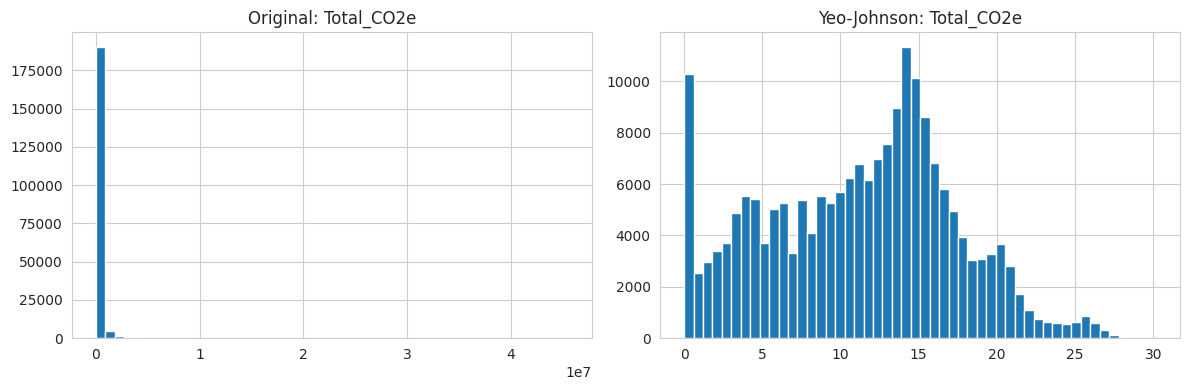

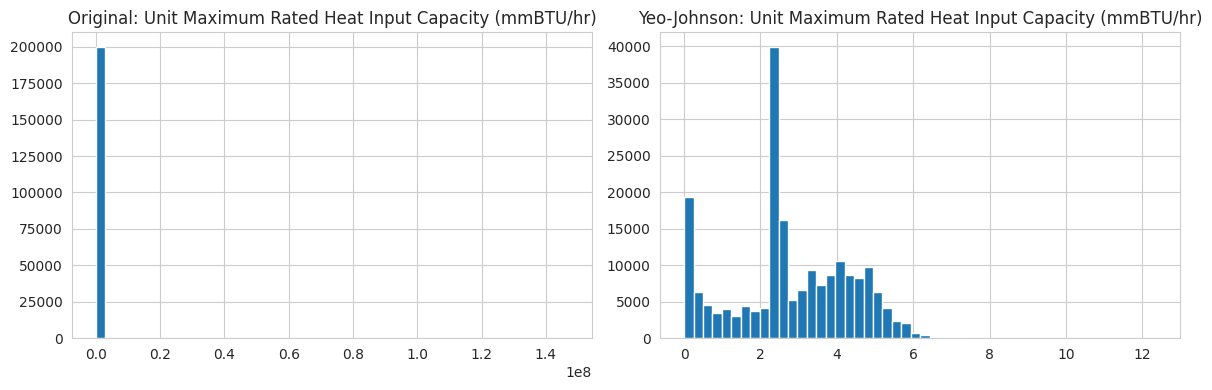

In [46]:
sample_size = 200_000  # plenty for distribution shape

for col in columns_to_transform:
    sample_orig = df[col].dropna().sample(sample_size, random_state=42)

    # Select correct transformed column
    if col == 'Total_CO2e':
        sample_trans = df[f'{col}_YeoJohnson'].dropna().sample(sample_size, random_state=42)
        trans_label = 'Yeo-Johnson'
    else:
        sample_trans = df[f'{col}_YeoJohnson'].dropna().sample(sample_size, random_state=42)
        trans_label = 'Yeo-Johnson'

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(sample_orig, bins=50)
    axes[0].set_title(f'Original: {col}')

    axes[1].hist(sample_trans, bins=50)
    axes[1].set_title(f'{trans_label}: {col}')

    plt.tight_layout()
    plt.show()


In [48]:
import tensorflow as tf

# ------------------------------------------------
# 1. Categorical columns
# ------------------------------------------------
categorical_cols = [
    'State',
    'Industry Type (sectors)',
    'Unit Type',
    'Primary NAICS Code'
]

# ------------------------------------------------
# 2. Store lookup layers & vocab sizes
# ------------------------------------------------
lookup_layers = {}
vocab_sizes = {}

# ------------------------------------------------
# 3. Fit & Apply Transformations
# ------------------------------------------------
print("Processing Categorical Columns...")

for col in categorical_cols:
    # 1. Ensure string format (critical for StringLookup)
    df[col] = df[col].astype(str)

    # 2. Initialize the layer
    # num_oov_indices=1 reserves index 0 or 1 for "Unknown" categories
    lookup = tf.keras.layers.StringLookup(
        output_mode="int",
        mask_token=None,    # If you don't need masking
        num_oov_indices=1   # Handles unseen categories safely
    )

    # 3. Adapt (Fit) the layer to the data
    lookup.adapt(df[col].values)

    # 4. Transform the column immediately (Strings -> Integers)
    # This creates the integer IDs your create_sequences function needs
    df[f'{col}_Id'] = lookup(df[col].values).numpy()

    # 5. Store Metadata
    lookup_layers[col] = lookup
    vocab_sizes[f'{col}_Id'] = lookup.vocabulary_size()

    print(f"  --> {col}: Vocab Size = {vocab_sizes[f'{col}_Id']}")

# Check the result
print("\nTransformed DataFrame Head:")
print(df[categorical_cols + [f'{c}_Id' for c in categorical_cols]].head().to_markdown(index=False))

Processing Categorical Columns...
  --> State: Vocab Size = 55
  --> Industry Type (sectors): Vocab Size = 76
  --> Unit Type: Vocab Size = 51
  --> Primary NAICS Code: Vocab Size = 341

Transformed DataFrame Head:
| State   | Industry Type (sectors)                                                          | Unit Type                     |   Primary NAICS Code |   State_Id |   Industry Type (sectors)_Id |   Unit Type_Id |   Primary NAICS Code_Id |
|:--------|:---------------------------------------------------------------------------------|:------------------------------|---------------------:|-----------:|-----------------------------:|---------------:|------------------------:|
| IN      | Chemicals                                                                        | Unknown                       |               325199 |          8 |                            5 |              8 |                      10 |
| CA      | Natural Gas and Natural Gas Liquids Suppliers, Petroleum and N

In [49]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the scaler
scaler = MinMaxScaler()

# 2. Select the columns you want to scale
cols_to_scale = [
    'Unit Maximum Rated Heat Input Capacity (mmBTU/hr)_YeoJohnson',
    'Total_CO2e_YeoJohnson'
]

# 3. Fit and transform all columns in one step
# This returns a numpy array, so we assign it back to new column names
df[['Capacity_Scaled', 'Total_CO2e_Scaled']] = scaler.fit_transform(df[cols_to_scale])

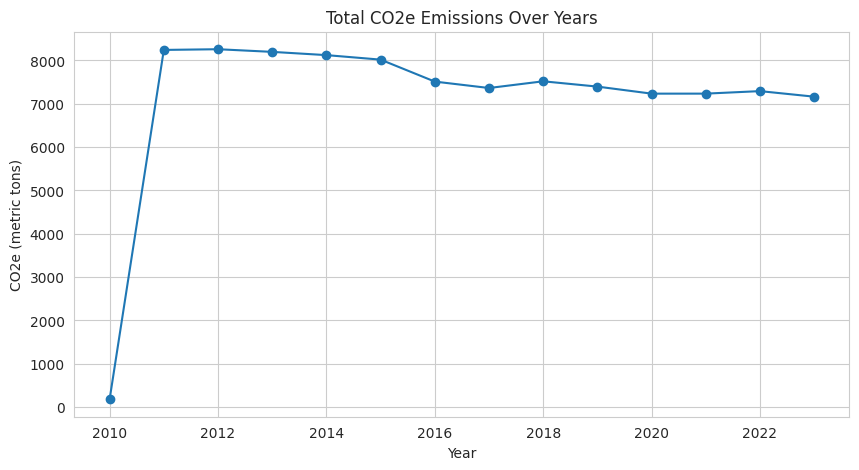

In [51]:
annual_total = df.groupby('Reporting Year')['Total_CO2e_Scaled'].sum()
plt.figure(figsize=(10,5))
annual_total.plot(marker='o')
plt.title('Total CO2e Emissions Over Years')
plt.xlabel('Year')
plt.ylabel('CO2e (metric tons)')
plt.grid(True)
plt.show()

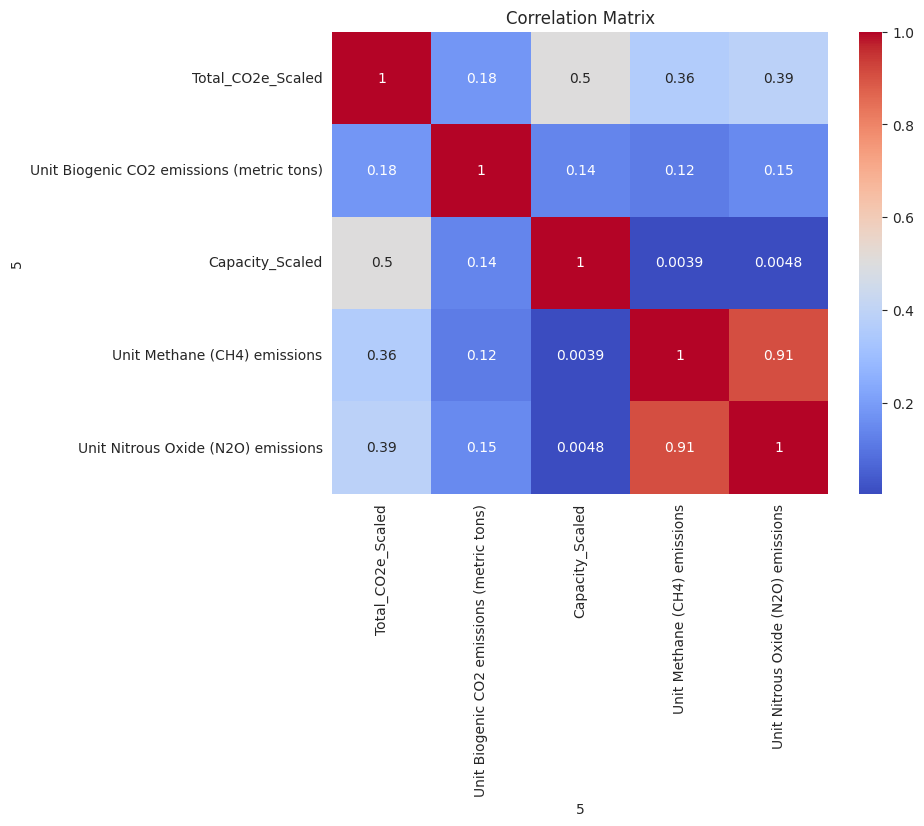

In [53]:
# --- Correlation Analysis ---
corr_matrix = df[['Total_CO2e_Scaled',
                  'Unit Biogenic CO2 emissions (metric tons)',
                  'Capacity_Scaled',
                  'Unit Methane (CH4) emissions',
                  'Unit Nitrous Oxide (N2O) emissions']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

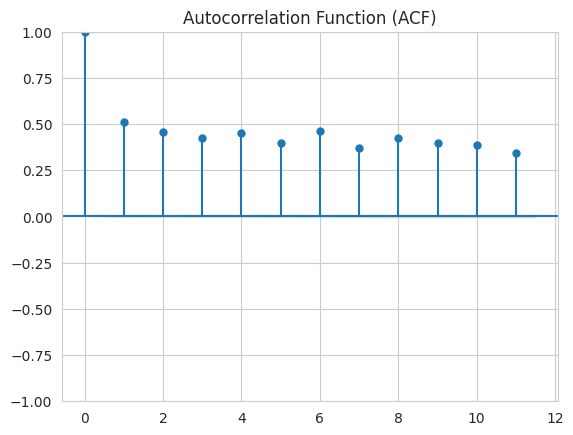

In [54]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Set lags to a reasonable number (e.g., 20 or max number of years in your data minus 1)
_ = plot_acf(df['Total_CO2e_Scaled'], lags=11)
plt.title('Autocorrelation Function (ACF)')
plt.show()

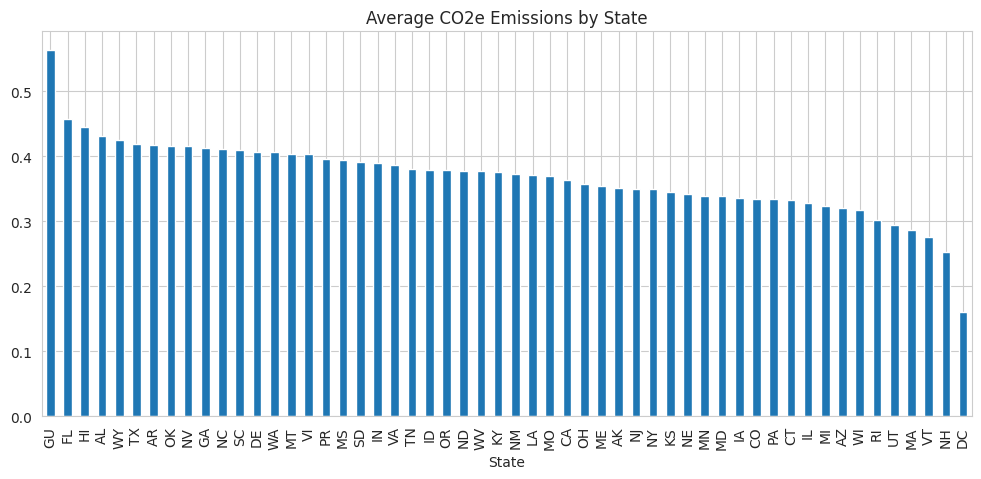

In [55]:
# --- Categorical Feature Analysis ---
# Average CO2e by state
state_emissions = df.groupby('State')['Total_CO2e_Scaled'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,5))
state_emissions.plot(kind='bar')
plt.title('Average CO2e Emissions by State')
plt.show()

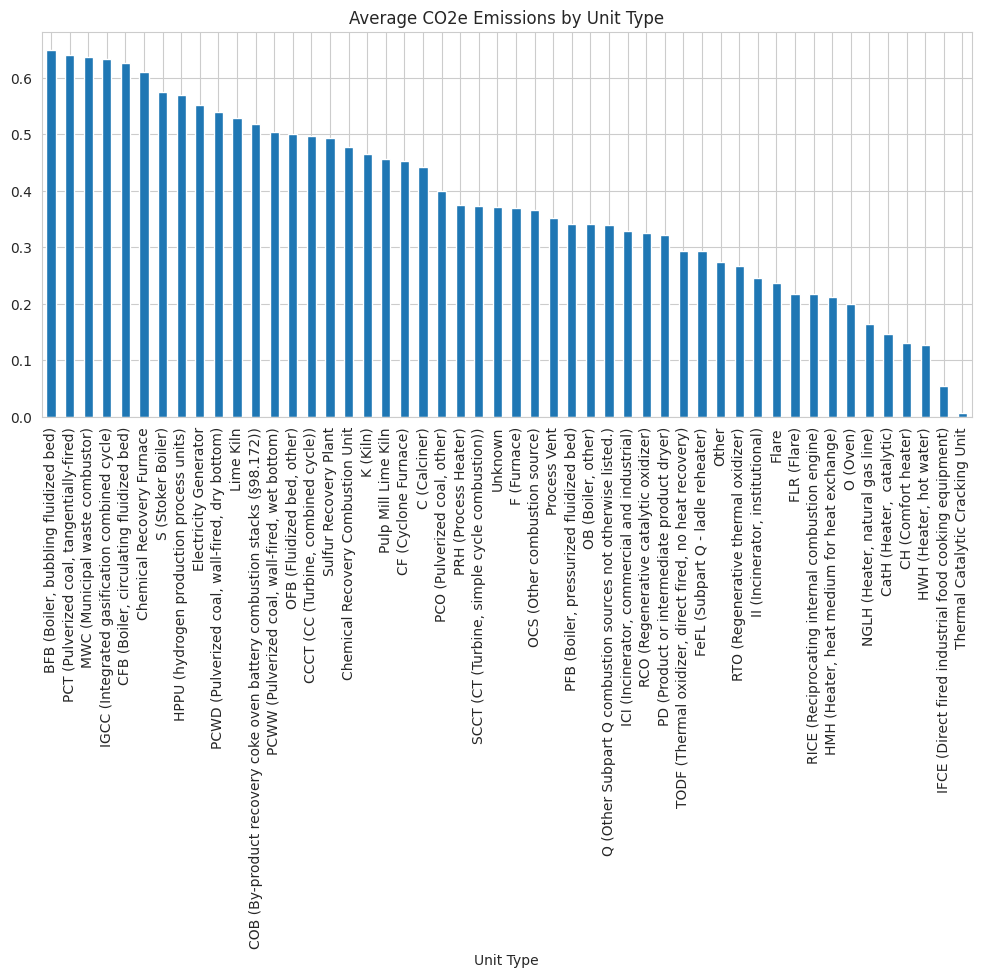

In [56]:
# Average CO2e by unit type
unit_emissions = df.groupby('Unit Type')['Total_CO2e_Scaled'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,5))
unit_emissions.plot(kind='bar')
plt.title('Average CO2e Emissions by Unit Type')
plt.show()

In [57]:
# Sorting and Series ID Creation
df['Series_ID'] = df['Facility Id'].astype(str) + "_" + df['Unit Name'].astype(str)
df = df.sort_values(by=['Series_ID', 'Reporting Year'])

So we created a series ID because there are many facilities and Each facility has many units also Each unit has values for different years so to track those Facility Id and Unit Name are not enough so we created a new variable that combines the two to fully identifies one physical emissions source. Then it sorts the dataset by Series_ID and within each Series_ID, sorts rows by year.

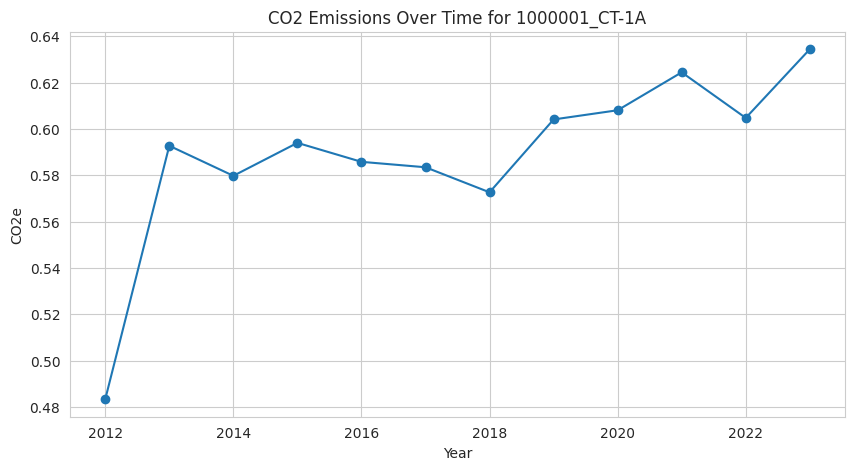

In [58]:
# --- Time-Series Patterns for Units ---
example_unit = df['Series_ID'].iloc[0]
unit_data = df[df['Series_ID'] == example_unit]
plt.figure(figsize=(10,5))
plt.plot(unit_data['Reporting Year'], unit_data['Total_CO2e_Scaled'], marker='o')
plt.title(f'CO2 Emissions Over Time for {example_unit}')
plt.xlabel('Year')
plt.ylabel('CO2e')
plt.grid(True)
plt.show()

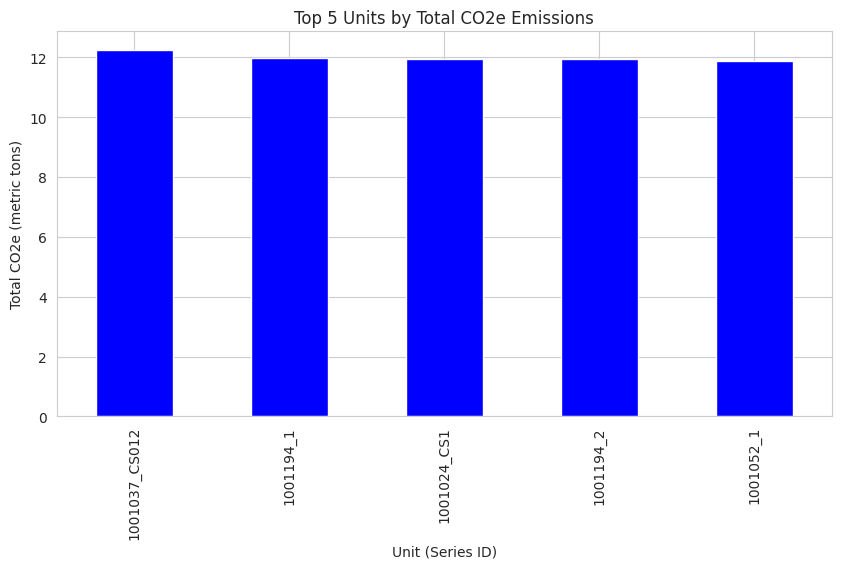

In [59]:
# --- Top 5 Units by Total CO2e ---
top_units = df.groupby('Series_ID')['Total_CO2e_Scaled'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
top_units.plot(kind='bar', color='blue')
plt.title('Top 5 Units by Total CO2e Emissions')
plt.ylabel('Total CO2e (metric tons)')
plt.xlabel('Unit (Series ID)')
plt.show()

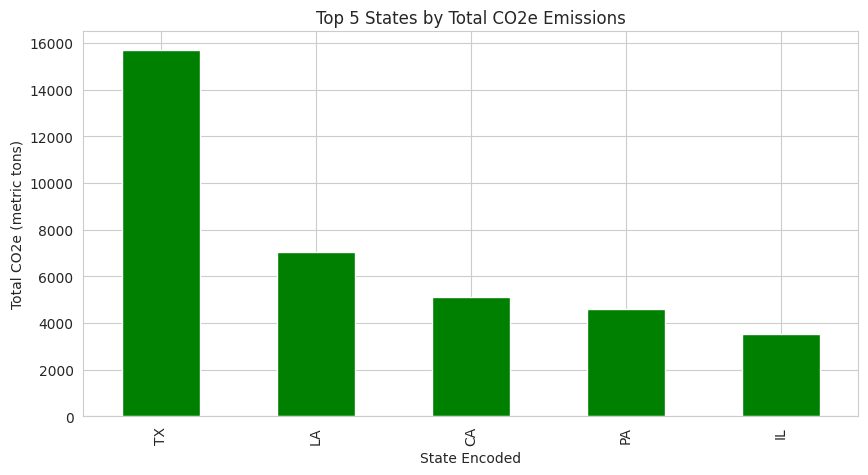

In [60]:
# --- Top 5 States by Total CO2e ---
top_states = df.groupby('State')['Total_CO2e_Scaled'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='green')
plt.title('Top 5 States by Total CO2e Emissions')
plt.ylabel('Total CO2e (metric tons)')
plt.xlabel('State Encoded')
plt.show()

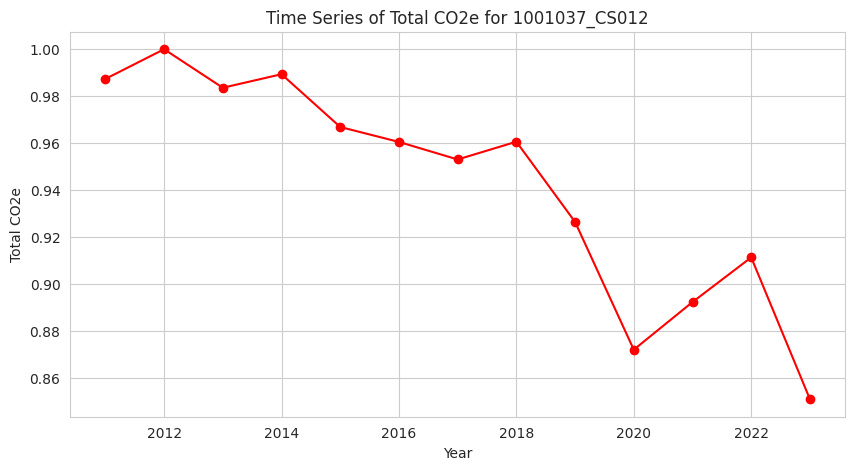

In [61]:
# --- Time Series for Top Unit ---
top_unit_id = top_units.index[0]
unit_data = df[df['Series_ID'] == top_unit_id]
plt.figure(figsize=(10,5))
plt.plot(unit_data['Reporting Year'], unit_data['Total_CO2e_Scaled'], marker='o', color='red')
plt.title(f'Time Series of Total CO2e for {top_unit_id}')
plt.xlabel('Year')
plt.ylabel('Total CO2e')
plt.grid(True)
plt.show()

In [65]:
df.to_csv("Green_house_cleaned.csv", index=False)

DATA IMBALANCE & DISTRIBUTION REPORT

 CATEGORICAL FEATURE BALANCE check


/tmp/ipython-input-1115281625.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.index, y=top_cats.values, palette='viridis')


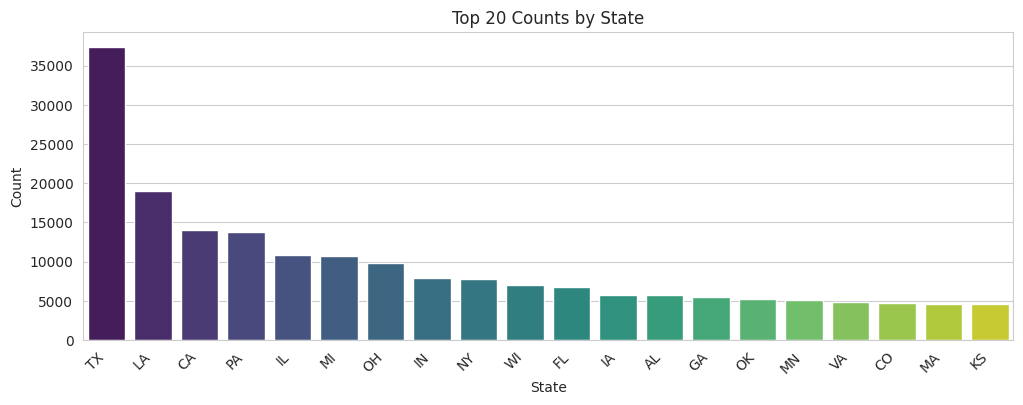

Imbalance Ratio for State (Top vs 20th): 8.22x difference



/tmp/ipython-input-1115281625.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.index, y=top_cats.values, palette='viridis')


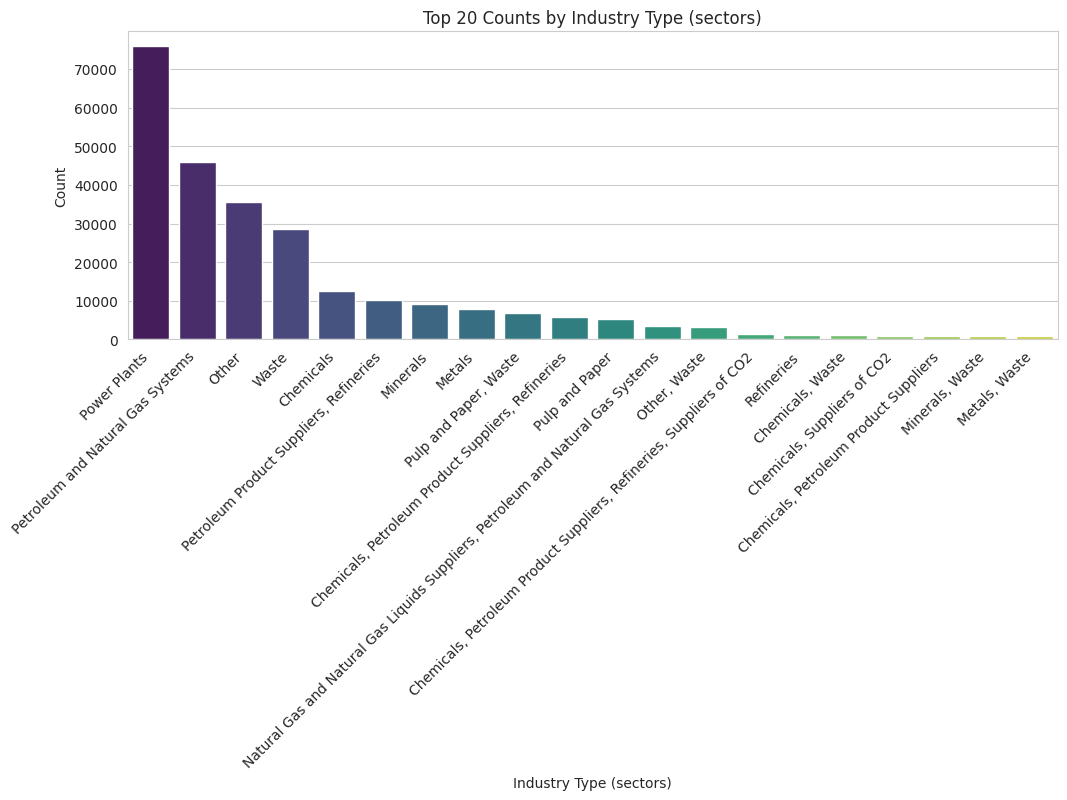

Imbalance Ratio for Industry Type (sectors) (Top vs 20th): 88.14x difference



/tmp/ipython-input-1115281625.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.index, y=top_cats.values, palette='viridis')


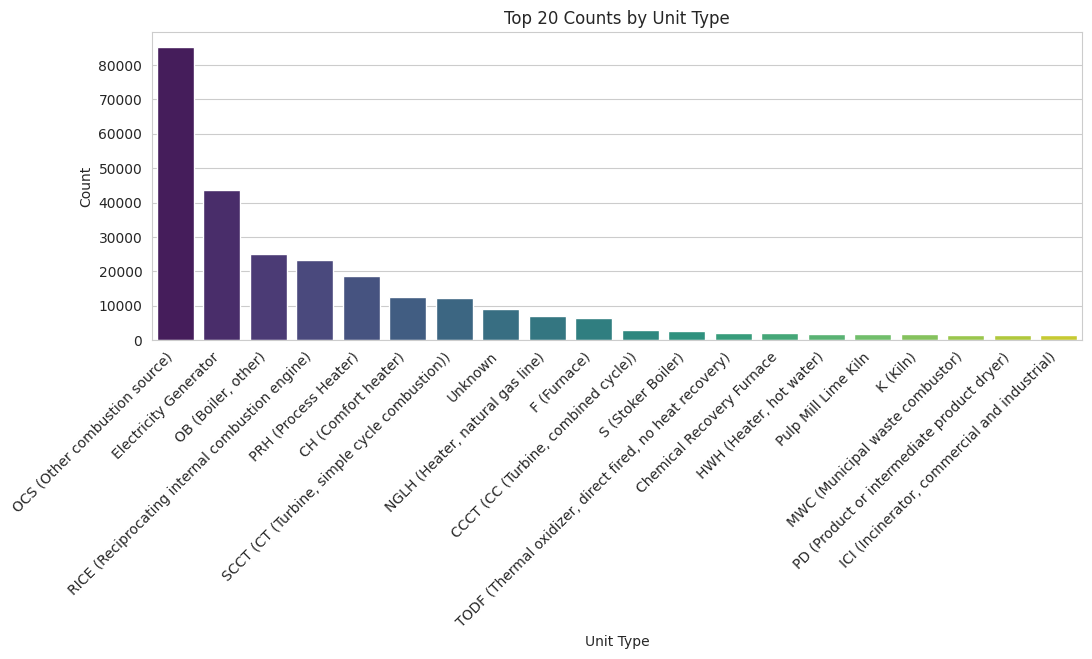

Imbalance Ratio for Unit Type (Top vs 20th): 60.61x difference



In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def check_data_imbalance(df):
    print("="*50)
    print("DATA IMBALANCE & DISTRIBUTION REPORT")
    print("="*50)

    # -------------------------------------------------------
    # Categorical Imbalance (Top Categories) check
    # -------------------------------------------------------
    print(f"\n CATEGORICAL FEATURE BALANCE check")

    cat_cols = ['State', 'Industry Type (sectors)', 'Unit Type']

    for col in cat_cols:
        if col in df.columns:
            plt.figure(figsize=(12, 4))
            # Get top 20 categories to avoid overcrowding plot
            top_cats = df[col].value_counts().nlargest(20)

            sns.barplot(x=top_cats.index, y=top_cats.values, palette='viridis')
            plt.title(f'Top 20 Counts by {col}')
            plt.xticks(rotation=45, ha='right')
            plt.ylabel('Count')
            plt.show()

            # Print imbalance ratio (Most frequent / Least frequent in top 20)
            ratio = top_cats.iloc[0] / top_cats.iloc[-1]
            print(f"Imbalance Ratio for {col} (Top vs 20th): {ratio:.2f}x difference\n")

# Run the function on your dataframe
check_data_imbalance(df)

In [63]:
# --- Sequence Generation Function ---
def create_sequences(df, lookback=6):  # lookback=6 means using past 6 years to predict the next year

    X_dynamic = []  # past years of dynamic features
    X_static = []   # static/categorical features
    Y_target = []   # target variable
    IDs = []

    # Define ID columns
    id_columns = ['Facility Name', 'State', 'Reporting Year', 'Unit Name']

    # ------------------------------------------------
    # ADD: Explicit zero-emission regime flag
    # ------------------------------------------------
    df['Is_Zero_Reported'] = (df['Total_CO2e_Scaled'] == 0).astype(int)

    # ------------------------------------------------
    # UPDATE: Dynamic features
    #   - Total_CO2e_Scaled (target history)
    #   - Capacity_YeoJohnson (better for zeros/extremes)
    #   - Is_Zero_Reported (regime signal)
    # ------------------------------------------------
    dynamic_features = [
        'Total_CO2e_Scaled',
        'Capacity_Scaled',
        'Is_Zero_Reported'
    ]

    # Static (categorical / embedding-ready)
    static_features = [c for c in df.columns if c.endswith('_Id')]

    # Iterate over each unit time series
    for series_id, group in df.groupby('Series_ID'):
        group = group.sort_values('Reporting Year')
        data = group[dynamic_features].values
        target = group['Total_CO2e_Scaled'].values

        # Static features (constant per unit)
        static_data = group[static_features].iloc[0].values

        # Metadata for traceability
        metadata = group[id_columns].values

        # Sliding window
        for i in range(len(data) - lookback):
            X_dynamic.append(data[i : i + lookback])
            Y_target.append(target[i + lookback])
            X_static.append(static_data)
            IDs.append(metadata[i + lookback])

    return np.array(X_dynamic), np.array(X_static), np.array(Y_target), np.array(IDs)


# ------------------------------------------------
# Generate sequences
# ------------------------------------------------
T = 6
X_dynamic, X_static, Y_target, IDs = create_sequences(df, lookback=T)

# Save arrays
np.savez_compressed(
    'sequence_data.npz',
    X_dynamic=X_dynamic,
    X_static=X_static,
    Y_target=Y_target
)

print("Sequences generated and saved!")
print("X_dynamic shape:", X_dynamic.shape)
print("X_static shape:", X_static.shape)
print("Y_target shape:", Y_target.shape)
print("IDs shape:", IDs.shape)


Sequences generated and saved!
X_dynamic shape: (104795, 6, 3)
X_static shape: (104795, 4)
Y_target shape: (104795,)
IDs shape: (104795, 4)


In [64]:
n = len(X_dynamic)

train_end = int(0.7 * n)
val_end   = int(0.8 * n)

# TRAIN
X_dyn_train  = X_dynamic[:train_end]
X_stat_train = X_static[:train_end]
Y_train      = Y_target[:train_end]

# VALIDATION
X_dyn_val  = X_dynamic[train_end:val_end]
X_stat_val = X_static[train_end:val_end]
Y_val      = Y_target[train_end:val_end]

# TEST
X_dyn_test  = X_dynamic[val_end:]
X_stat_test = X_static[val_end:]
Y_test      = Y_target[val_end:]
IDs_test    = IDs[val_end:]
print("Training set size:", X_dyn_train.shape[0])
print("Validation set size:", X_dyn_val.shape[0])
print("Test set size:", X_dyn_test.shape[0])

# Combine inputs to match model signature
train_inputs = [X_dyn_train, X_stat_train]
val_inputs   = [X_dyn_val, X_stat_val]
test_inputs  = [X_dyn_test, X_stat_test]


Training set size: 73356
Validation set size: 10480
Test set size: 20959


MODEL





In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_model(dynamic_shape, static_shape):
    # ---------------------------
    # Dynamic Input (LSTM branch)
    # ---------------------------
    dyn_input = layers.Input(shape=dynamic_shape, name='dynamic_input')
    x = layers.LSTM(64, return_sequences=True)(dyn_input)
    x = layers.LSTM(32)(x)

    # ---------------------------
    # Static Input (Dense branch)
    # ---------------------------
    stat_input = layers.Input(shape=static_shape, name='static_input')
    y = layers.Dense(16, activation='relu')(stat_input)

    # ---------------------------
    # Combine
    # ---------------------------
    combined = layers.concatenate([x, y])
    z = layers.Dense(16, activation='relu')(combined)
    output = layers.Dense(1, name='output')(z)

    model = models.Model(
        inputs=[dyn_input, stat_input],
        outputs=output
    )

    # ---------------------------
    # Compile
    # ---------------------------
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='huber',
        metrics=['mae']
    )

    return model


In [ ]:
# --- STEP 2: CALLBACKS ---
import os
import random

def set_reproducibility(seed=42):
    # 1. Set Python environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. Set Python built-in random seed
    random.seed(seed)

    # 3. Set NumPy seed
    np.random.seed(seed)

    # 4. Set TensorFlow seed
    tf.random.set_seed(seed)

    # 5. Optional: Force TensorFlow to use deterministic operations
    # Note: This may slow down training slightly
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Call the function
set_reproducibility(42)

# Reduces learning rate when validation loss plateaus
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

class Log5(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            print(f"\n📊 PERFORMANCE CHECK - EPOCH {epoch + 1}")
            print(f"Train Loss: {logs['loss']:.6f} | Val Loss: {logs['val_loss']:.6f}")


# ------------------------------------------------
# BUILD MODEL (THIS IS THE MISSING STEP)
# ------------------------------------------------
dynamic_shape = X_dyn_train.shape[1:]   # (T, num_dynamic_features)
static_shape  = X_stat_train.shape[1:]  # (num_static_features,)

# Setup Checkpoint to save the best model automatically
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'LSTM_best.keras', monitor='val_loss', save_best_only=True, verbose=1
)

# This wipes the old weights and creates a fresh, random starting point
tf.keras.backend.clear_session()
model = build_model(dynamic_shape, static_shape)

# Optional but recommended
model.summary()

# --- STEP 3: TRAIN ---
history = model.fit(
    x=train_inputs,
    y=Y_train,
    validation_data=(val_inputs, Y_val),
    epochs=100,
    batch_size=64, # Smaller batch size can help generalization
    verbose=1,
    callbacks=[early_stop, lr_reducer, Log5(), checkpoint]
)

In [ ]:
import matplotlib.pyplot as plt

# Start plotting from epoch 5 to ignore the initial spike
plt.plot(history.history['loss'][5:], label='Training Loss')
plt.plot(history.history['val_loss'][5:], label='Validation Loss')
plt.title('Model Loss (Zoomed)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions
y_pred = model.predict(val_inputs).flatten()
y_true = Y_val.flatten()

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Calculate Percentage Error (MAPE) - assuming no zeros in data
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score (Accuracy)'],
    'Value': [f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}"]
})

print("--- MODEL PERFORMANCE SUMMARY ---")
print(metrics_df)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_gru_model(dynamic_shape, static_shape):
    # ---------------------------
    # Dynamic Input (GRU branch)
    # ---------------------------
    # We use 'dynamic_input' to stay consistent with your prediction script
    dyn_input = layers.Input(shape=dynamic_shape, name='dynamic_input')

    # Using GRU instead of LSTM
    # GRU has fewer parameters, making it faster and sometimes more robust
    x = layers.GRU(64, return_sequences=True, name='gru_1')(dyn_input)
    x = layers.GRU(32, name='gru_2')(x)

    # ---------------------------
    # Static Input (Dense branch)
    # ---------------------------
    stat_input = layers.Input(shape=static_shape, name='static_input')
    y = layers.Dense(16, activation='relu')(stat_input)

    # ---------------------------
    # Combine (Concatenation)
    # ---------------------------
    combined = layers.concatenate([x, y])

    # Adding a Dropout layer is a "Best Practice" for GRUs to prevent overfitting
    z = layers.Dense(16, activation='relu')(combined)
    z = layers.Dropout(0.1)(z)

    output = layers.Dense(1, name='output')(z)

    model = models.Model(
        inputs=[dyn_input, stat_input],
        outputs=output
    )

    # ---------------------------
    # Compile
    # ---------------------------
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.0001),
        loss='huber', # Keeps the robustness against outliers
        metrics=['mae']
    )

    return model



In [ ]:
import tensorflow as tf
import os
import random

def set_reproducibility(seed=42):
    # 1. Set Python environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. Set Python built-in random seed
    random.seed(seed)

    # 3. Set NumPy seed
    np.random.seed(seed)

    # 4. Set TensorFlow seed
    tf.random.set_seed(seed)

    # 5. Optional: Force TensorFlow to use deterministic operations
    # Note: This may slow down training slightly
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Call the function
set_reproducibility(42)

# --- STEP 1: DEFINE CALLBACKS ---

# Reduces learning rate when validation loss plateaus
# This is great for GRUs to "fine-tune" the weights as they approach the minimum
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Stops training if val_loss doesn't improve for 15 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Your custom callback for periodic updates
class Log5(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            print(f"\n📊 PERFORMANCE CHECK - EPOCH {epoch + 1}")
            print(f"Train Loss: {logs['loss']:.6f} | Val Loss: {logs['val_loss']:.6f}")

# --- STEP 2: BUILD THE GRU MODEL ---

# Automatically detect shapes from your split data
dynamic_shape = X_dyn_train.shape[1:]  # (Timesteps, num_dynamic_features)
static_shape  = X_stat_train.shape[1:]  # (num_static_features,)

# Setup Checkpoint to save the best model automatically
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'GRU_Best.keras', monitor='val_loss', save_best_only=True, verbose=1
)

# This wipes the old weights and creates a fresh, random starting point
tf.keras.backend.clear_session()
# Initialize the GRU version
model = build_gru_model(dynamic_shape, static_shape)

# Show structure and parameter count
model.summary()

# --- STEP 3: TRAIN ---

# Note: Using your existing train_inputs/val_inputs lists
# Keras will automatically map these to 'dynamic_input' and 'static_input'
# based on the order they appear in the model definition.
history = model.fit(
    x=train_inputs,
    y=Y_train,
    validation_data=(val_inputs, Y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, lr_reducer, Log5(), checkpoint]
)

In [ ]:
import matplotlib.pyplot as plt

# Start plotting from epoch 5 to ignore the initial spike
plt.plot(history.history['loss'][5:], label='Training Loss')
plt.plot(history.history['val_loss'][5:], label='Validation Loss')
plt.title('Model Loss (Zoomed)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions
y_pred = model.predict(val_inputs).flatten()
y_true = Y_val.flatten()

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Calculate Percentage Error (MAPE) - assuming no zeros in data
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score (Accuracy)'],
    'Value': [f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}"]
})

print("--- MODEL PERFORMANCE SUMMARY ---")
print(metrics_df)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_hybrid_lstm_gru_model(dynamic_shape, static_shape):
    # =====================================================
    # Dynamic Input
    # =====================================================
    dyn_input = layers.Input(
        shape=dynamic_shape,
        name='dynamic_input'
    )

    # ---------------------------
    # LSTM Branch (Long-term memory)
    # ---------------------------
    lstm_x = layers.LSTM(64,return_sequences=True,name='lstm_1')(dyn_input)
    lstm_x = layers.LSTM(32,name='lstm_2')(lstm_x)

    # ---------------------------
    # GRU Branch (Fast & robust)
    # ---------------------------
    gru_x = layers.GRU(64,return_sequences=True,name='gru_1')(dyn_input)
    gru_x = layers.GRU(32,name='gru_2')(gru_x)

    # =====================================================
    # Static Input Branch
    # =====================================================
    stat_input = layers.Input(shape=static_shape,name='static_input')
    stat_x = layers.Dense(16,activation='relu',name='static_dense')(stat_input)

    # =====================================================
    # Fusion
    # =====================================================
    combined = layers.concatenate([lstm_x, gru_x, stat_x],name='feature_fusion')

    # =====================================================
    # Final Regressor
    # =====================================================
    z = layers.Dense(32,activation='relu',name='fusion_dense_1')(combined)

    z = layers.Dropout(0.2,name='fusion_dropout')(z)

    z = layers.Dense(16,activation='relu',name='fusion_dense_2')(z)

    output = layers.Dense(1,name='output')(z)

    # =====================================================
    # Model
    # =====================================================
    model = models.Model(inputs=[dyn_input, stat_input],outputs=output,name='Hybrid_LSTM_GRU_Model')

    # =====================================================
    # Compile
    # =====================================================
    model.compile(optimizer=optimizers.Adam(learning_rate=0.0001),loss='huber',metrics=['mae'])

    return model


In [ ]:
import tensorflow as tf

# --- STEP 1: DEFINE CALLBACKS ---
import os
import random

def set_reproducibility(seed=42):
    # 1. Set Python environment variables
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. Set Python built-in random seed
    random.seed(seed)

    # 3. Set NumPy seed
    np.random.seed(seed)

    # 4. Set TensorFlow seed
    tf.random.set_seed(seed)

    # 5. Optional: Force TensorFlow to use deterministic operations
    # Note: This may slow down training slightly
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Call the function
set_reproducibility(42)

# Reduces learning rate when validation loss plateaus
# This is great for GRUs to "fine-tune" the weights as they approach the minimum
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
)

# Stops training if val_loss doesn't improve for 15 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

# Your custom callback for periodic updates
class Log5(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            print(f"\n📊 PERFORMANCE CHECK - EPOCH {epoch + 1}")
            print(f"Train Loss: {logs['loss']:.6f} | Val Loss: {logs['val_loss']:.6f}")

# --- STEP 2: BUILD THE HYBRID MODEL ---

# Automatically detect shapes from your split data
dynamic_shape = X_dyn_train.shape[1:]  # (Timesteps, num_dynamic_features)
static_shape  = X_stat_train.shape[1:]  # (num_static_features,)

# Setup Checkpoint to save the best model automatically
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'HYBRID_model.keras', monitor='val_loss', save_best_only=True, verbose=1
)

# This wipes the old weights and creates a fresh, random starting point
tf.keras.backend.clear_session()
# Initialize the Hybrid version
model = build_hybrid_lstm_gru_model(dynamic_shape, static_shape)

# Show structure and parameter count
model.summary()

# --- STEP 3: TRAIN ---

# Note: Using your existing train_inputs/val_inputs lists
# Keras will automatically map these to 'dynamic_input' and 'static_input'
# based on the order they appear in the model definition.
history = model.fit(
    x=train_inputs,
    y=Y_train,
    validation_data=(val_inputs, Y_val),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop, lr_reducer, Log5(), checkpoint]
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate predictions
y_pred = model.predict(val_inputs).flatten()
y_true = Y_val.flatten()

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

# Calculate Percentage Error (MAPE) - assuming no zeros in data
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score (Accuracy)'],
    'Value': [f"{mae:.4f}", f"{rmse:.4f}", f"{r2:.4f}"]
})

print("--- MODEL PERFORMANCE SUMMARY ---")
print(metrics_df)

In [ ]:
import matplotlib.pyplot as plt

# Start plotting from epoch 5 to ignore the initial spike
plt.plot(history.history['loss'][5:], label='Training Loss')
plt.plot(history.history['val_loss'][5:], label='Validation Loss')
plt.title('Model Loss (Zoomed)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
# ============================================================
# SAVE ARTIFACTS (UPDATED FOR SCALED CAPACITY)
# ============================================================

import os
import json
import numpy as np
from joblib import dump

# 1. Create Directory
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 2. Save Yeo–Johnson Lambdas
# (Same as before - we need these to transform raw numbers BEFORE scaling)
yeojohnson_lambdas = {
    "Total_CO2e": float(lambda_values["Total_CO2e"]),
    "Unit Maximum Rated Heat Input Capacity (mmBTU/hr)": float(
        lambda_values["Unit Maximum Rated Heat Input Capacity (mmBTU/hr)"]
    )
}
with open(os.path.join(ARTIFACT_DIR, "yeojohnson_lambdas.json"), "w") as f:
    json.dump(yeojohnson_lambdas, f, indent=4)

# 3. Save MinMaxScaler (UPDATED)
# IMPORTANT: This scaler object now contains the Min/Max for BOTH columns.
# It expects a 2D array: [[Capacity_YJ, CO2_YJ]]
dump(scaler, os.path.join(ARTIFACT_DIR, "minmax_scaler.joblib"))
print("✔ Saved Scaler for both Capacity and CO2")

# 4. Save Vocabularies (JSON) - With Safety Cast
vocab_storage = {}
for col, lookup in lookup_layers.items():
    # get_vocabulary() might return numpy types, cast to standard list of strings
    vocab = [str(v) for v in lookup.get_vocabulary()]
    vocab_storage[col] = vocab

with open(os.path.join(ARTIFACT_DIR, "vocabularies.json"), "w") as f:
    json.dump(vocab_storage, f, indent=4)

# 5. Save Feature Config (UPDATED)
feature_config = {
    "lookback": 6,
    "dynamic_features": [
        "Total_CO2e_Scaled",
        "Capacity_Scaled",  # Matches your new sequence logic
        "Is_Zero_Reported"
    ],
    "static_features": [f"{c}_Id" for c in categorical_cols],
    "scaler_features_order": [
        "Unit Maximum Rated Heat Input Capacity (mmBTU/hr)_YeoJohnson",
        "Total_CO2e_YeoJohnson"
    ]
}
with open(os.path.join(ARTIFACT_DIR, "feature_config.json"), "w") as f:
    json.dump(feature_config, f, indent=4)

print("🎯 Artifacts updated for Scaled Capacity.")

I worte this code to not always run the model traning again and again

In [ ]:
import tensorflow as tf
model_gru = tf.keras.models.load_model(r'/content/GRU_Best.keras')

In [ ]:
import tensorflow as tf
model_lstm = tf.keras.models.load_model(r'/content/LSTM_best.keras')

In [ ]:
import tensorflow as tf
model_hybrid = tf.keras.models.load_model(r'/content/HYBRID_model.keras')

In [ ]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

# --- 1. Helper Functions ---

def get_model_metrics(model, model_name, X_dyn, X_stat, Y_true):
    """
    Runs predictions, times them, and calculates standard metrics.
    Handles both Single-Input (Sequential) and Multi-Input (Functional) models.
    """
    print(f"Evaluating {model_name}...")

    start_time = time.time()

    try:
        if isinstance(model.input, list) and len(model.input) > 1:
            preds = model.predict([X_dyn, X_stat], verbose=0)
        else:
            preds = model.predict(X_dyn, verbose=0)
    except Exception:
        preds = model.predict([X_dyn, X_stat], verbose=0)

    inference_time = time.time() - start_time

    preds = preds.flatten()

    mae = mean_absolute_error(Y_true, preds)
    rmse = np.sqrt(mean_squared_error(Y_true, preds))
    r2 = r2_score(Y_true, preds)

    params = model.count_params()

    return {
        "Model": model_name,
        "MAE (Scaled)": mae,
        "RMSE (Scaled)": rmse,
        "R2 Score": r2,
        "Inference Time (s)": inference_time,
        "Parameters": params,
        "Predictions": preds
    }

def diebold_mariano_test(real, pred1, pred2, criterion="MSE"):
    """
    Diebold-Mariano test for equal predictive accuracy.
    """
    e1 = np.array(real) - np.array(pred1)
    e2 = np.array(real) - np.array(pred2)

    if criterion == "MSE":
        d = e1**2 - e2**2
    else:  # MAE
        d = np.abs(e1) - np.abs(e2)

    T = len(d)
    d_mean = np.mean(d)

    var_d = np.var(d) / T if T > 1 else 1e-6

    dm_stat = d_mean / np.sqrt(var_d)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return p_value, d_mean

# --- 2. Main Execution ---

results = []
predictions_dict = {}

models_map = {
    "GRU": model_gru,
    "LSTM": model_lstm
}

for name, model in models_map.items():
    metrics = get_model_metrics(model, name, X_dynamic, X_static, Y_target)
    predictions_dict[name] = metrics.pop("Predictions")
    results.append(metrics)

df_results = pd.DataFrame(results).set_index("Model")

# --- 3. Diebold–Mariano Test (LSTM vs GRU) ---

print("\n--- Statistical Significance Test (Diebold-Mariano) ---")
print("Null Hypothesis: LSTM and GRU have equal predictive accuracy.\n")

p_value, d_mean = diebold_mariano_test(
    Y_target,
    predictions_dict["LSTM"],
    predictions_dict["GRU"],
    criterion="MSE"
)

significance = "SIGNIFICANT" if p_value < 0.05 else "NOT Significant"

# Direction interpretation
if p_value < 0.05:
    if d_mean < 0:
        direction = "LSTM performs BETTER than GRU"
    else:
        direction = "GRU performs BETTER than LSTM"
else:
    direction = "No clear winner (performance difference is not reliable)"

# --- 4. Final Report ---

print("--- Model Performance Scorecard ---")
print(df_results)
print("\n" + "=" * 55)
print(f"LSTM vs GRU: p-value = {p_value:.4f} -> {significance}")
print(f"Direction: {direction}")
print("=" * 55)

print("\nInterpretation:")
print(
    "The Diebold–Mariano test evaluates whether the difference in forecast errors "
    "between LSTM and GRU is statistically meaningful. "
    "When significant, the direction is determined by which model has lower average loss."
)


Evaluating GRU...
Evaluating LSTM...

--- Statistical Significance Test (Diebold-Mariano) ---
Null Hypothesis: LSTM and GRU have equal predictive accuracy.

--- Model Performance Scorecard ---
       MAE (Scaled)  RMSE (Scaled)  R2 Score  Inference Time (s)  Parameters
Model                                                                       
GRU        0.026477       0.050589  0.936890           10.013268       23537
LSTM       0.028025       0.052448  0.932167            8.408927       30705

LSTM vs GRU: p-value = 0.0000 -> SIGNIFICANT
Direction: GRU performs BETTER than LSTM

Interpretation:
The Diebold–Mariano test evaluates whether the difference in forecast errors between LSTM and GRU is statistically meaningful. When significant, the direction is determined by which model has lower average loss.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model # <--- Import this

# ==========================================
# 1. INVERSE TRANSFORMATION HELPER
# ==========================================
def inverse_yeojohnson(y, lmbda):
    """Reverses the Yeo-Johnson transformation"""
    if lmbda != 0:
        base = y * lmbda + 1
        return np.sign(base) * np.power(np.abs(base), 1 / lmbda) - 1
    else:
        return np.exp(y) - 1

# ==========================================
# 2. PREPARE 2024 INPUT (Fast ID-based Logic)
# ==========================================
def prepare_2024_forecast_data(df, lookback=6):
    X_dynamic = []
    X_static = []
    IDs = []

    # ID columns for the report
    id_cols = ['Facility Name', 'State', 'Unit Name']

    # Ensure these features exactly match what you trained on
    dynamic_features = [
        'Total_CO2e_Scaled',
        'Capacity_Scaled',
        'Is_Zero_Reported'
    ]
    # Ensure this matches your training static features exactly
    static_features = [c for c in df.columns if c.endswith('_Id')]

    for series_id, group in df.groupby('Series_ID'):
        group = group.sort_values('Reporting Year')

        # We take the LAST 'lookback' years to predict the NEXT year (2024)
        if len(group) >= lookback:
            data = group[dynamic_features].tail(lookback).values.astype('float32')
            static_data = group[static_features].iloc[-1].values.astype('float32')
            metadata = group[id_cols].iloc[-1].values

            X_dynamic.append(data)
            X_static.append(static_data)
            IDs.append(metadata)

    return np.array(X_dynamic), np.array(X_static), np.array(IDs)

# ==========================================
# 2.5. LOAD YOUR SAVED MODEL
# ==========================================
print("Loading 'GRU_Best.keras' model...")
# This loads the architecture + weights + optimizer state
model = load_model('GRU_Best.keras')

# ==========================================
# 3. GENERATE THE 2024 PREDICTIONS
# ==========================================
print("Extracting latest data for 2024 forecast...")
# Ensure 'df' is the dataframe containing your scaler/transformed data up to 2023
X_dyn_2024, X_stat_2024, IDs_2024 = prepare_2024_forecast_data(df, lookback=6)

print(f"Predicting 2024 emissions for {len(X_dyn_2024)} units...")
y_pred_scaled = model.predict([X_dyn_2024, X_stat_2024], verbose=1)

# --- Inverse Scale (Assuming scaler matches training) ---
# Note: Ensure 'scaler' and 'lambda_values' are available in memory
dummy_pred = np.zeros((len(y_pred_scaled), 2)) # Shape (N, 2) because scaler expects 2 cols
dummy_pred[:, 1] = y_pred_scaled.flatten()     # Fill the target column (assuming it was index 1)
y_pred_yj = scaler.inverse_transform(dummy_pred)[:, 1]

# --- Inverse Yeo-Johnson ---
lambda_val = lambda_values['Total_CO2e']
y_pred_real_2024 = inverse_yeojohnson(y_pred_yj, lambda_val)

# ==========================================
# 4. CREATE THE FINAL 2024 REPORT
# ==========================================
# 1. Map predictions back to Facility Names
forecast_df = pd.DataFrame(IDs_2024, columns=['Facility Name', 'State', 'Unit Name'])
forecast_df['Predicted_CO2_2024'] = y_pred_real_2024

# 2. Aggregate by Facility (Sum all units)
facility_forecast = forecast_df.groupby(['Facility Name', 'State']).agg({
    'Predicted_CO2_2024': 'sum'
}).reset_index()

# 3. Add 2023 Actuals for comparison (to show Trend)
# Ensure 'df' contains the raw (unscaled) 2023 data for this comparison,
# or load the original raw CSV separately if 'df' is fully transformed.
last_actuals = df[df['Reporting Year'] == 2023].groupby('Facility Name')['Total_CO2e'].sum().reset_index()

facility_forecast = facility_forecast.merge(last_actuals, on='Facility Name', how='left')
facility_forecast.rename(columns={'Total_CO2e': 'Actual_CO2_2023'}, inplace=True)

# Calculate expected change
facility_forecast['Expected_Change'] = facility_forecast['Predicted_CO2_2024'] - facility_forecast['Actual_CO2_2023']

# ==========================================
# 5. DISPLAY THE OUTPUT
# ==========================================
print("\n" + "="*95)
print(f"{'2024 FACILITY EMISSIONS FORECAST (MODEL: GRU_Best.keras)':^95}")
print("="*95)

# Display top 10 facilities formatted as a table
print(facility_forecast[['Facility Name', 'State', 'Actual_CO2_2023', 'Predicted_CO2_2024', 'Expected_Change']].head(10).to_markdown(index=False))

print("\n" + "="*95)
total_2024 = facility_forecast['Predicted_CO2_2024'].sum()
print(f"TOTAL PREDICTED EMISSIONS FOR 2024: {total_2024:,.2f} Metric Tons")
print("="*95)

Loading 'GRU_Best.keras' model...
Extracting latest data for 2024 forecast...
Predicting 2024 emissions for 20727 units...
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

                   2024 FACILITY EMISSIONS FORECAST (MODEL: GRU_Best.keras)                    
| Facility Name                                        | State   |   Actual_CO2_2023 |   Predicted_CO2_2024 |   Expected_Change |
|:-----------------------------------------------------|:--------|------------------:|---------------------:|------------------:|
| 1500 South Tibbs LLC d/b/a Aurorium Indianapolis LLC | IN      |           76337.1 |            72519.3   |        -3817.74   |
| 23rd and 3rd                                         | NY      |           37580.8 |            40842.8   |         3262.04   |
| 31st Street Landfill                                 | IL      |             248.7 |              319.453 |           70.7529 |
| 3M BROWNWOOD                                         | TX      |           26896.9 |   

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model

# ==========================================
# 0. SETUP & LOAD MODEL
# ==========================================
# Ensure scaler and lambda_values are in memory from your training step!
model = load_model('GRU_Best.keras')
lambda_val = lambda_values['Total_CO2e']

# ==========================================
# 1. HELPER: INVERSE TRANSFORMS
# ==========================================
def inverse_yeojohnson_single(y, lmbda):
    """Reverses Yeo-Johnson for a single value or array"""
    if lmbda != 0:
        base = y * lmbda + 1
        # Avoid invalid values for power operation
        base = np.where(base < 0, 0, base)
        return np.sign(base) * np.power(np.abs(base), 1 / lmbda) - 1
    else:
        return np.exp(y) - 1

def inverse_scale_prediction(pred_scaled_value, scaler):
    """Reverses the MinMax/Standard Scaler. Assumes 2 columns (Heat, CO2)."""
    # Create a dummy array of shape (N, 2) to satisfy the scaler's shape requirement
    # We assume CO2 is at index 1 based on your previous code
    dummy = np.zeros((len(pred_scaled_value), 2))
    dummy[:, 1] = pred_scaled_value.flatten()
    return scaler.inverse_transform(dummy)[:, 1]

# ==========================================
# 2. PREPARE INITIAL DATA (The starting point)
# ==========================================
# Get the input window ending in 2023 (to predict 2024 first)
print("Initializing data for multi-year forecast...")
current_dynamic, static_data, IDs = prepare_2024_forecast_data(df, lookback=6)

# Store results: Dictionary of {Year: [Predictions]}
forecast_results = {}
years_to_predict = [2024, 2025, 2026, 2027, 2028]

# ==========================================
# 3. THE FORECASTING LOOP (5 Years)
# ==========================================
print(f"Starting autoregressive forecast for {years_to_predict}...")

# We use a copy so we don't mess up the original data
X_dyn_curr = current_dynamic.copy()

for year in years_to_predict:
    print(f"  -> Predicting {year}...")

    # A. Predict Next Year (Output is Scaled + Yeo-Johnsoned)
    pred_scaled = model.predict([X_dyn_curr, static_data], verbose=0)

    # B. Inverse Transform to get Real CO2 (Metric Tons)
    # 1. Inverse Scale
    pred_yj = inverse_scale_prediction(pred_scaled, scaler)
    # 2. Inverse Yeo-Johnson
    pred_real = inverse_yeojohnson_single(pred_yj, lambda_val)

    # Save real values for the report
    forecast_results[year] = pred_real

    # C. UPDATE THE WINDOW FOR THE NEXT ITERATION
    # The model needs shape (N, 6, 3). We need to shift the window left.
    # Feature order assumption: [HeatInput, CO2, IsZero] or similar.
    # CRITICAL: You must know which index is CO2 in X_dynamic.
    # Based on your prepare function:
    # Index 0: Total_CO2e_Scaled
    # Index 1: Heat Input
    # Index 2: Is_Zero

    # 1. Create the new timestep (Shape: N, 1, 3)
    new_timestep = np.zeros((len(pred_scaled), 1, 3))

    # Feature 0: The predicted CO2 (Keep it SCALED because the model expects scaled inputs)
    # Note: The model output `pred_scaled` is shape (N, 1).
    # We put the SCALED prediction back into the loop, not the real one.
    new_timestep[:, 0, 0] = pred_scaled.flatten()

    # Feature 1 (Heat Input) & Feature 2 (Is_Zero):
    # We copy the values from the previous year (Naive assumption: operations stay constant)
    last_known_values = X_dyn_curr[:, -1:, :] # Shape (N, 1, 3)
    new_timestep[:, 0, 1] = last_known_values[:, 0, 1] # Copy Heat Input
    new_timestep[:, 0, 2] = last_known_values[:, 0, 2] # Copy Is_Zero flag

    # 2. Shift Window: Drop first year (index 0), append new year
    # X_dyn_curr shape becomes (N, 5, 3) -> append -> (N, 6, 3)
    X_dyn_curr = np.concatenate([X_dyn_curr[:, 1:, :], new_timestep], axis=1)

# ==========================================
# 4. BUILD THE REPORT
# ==========================================
# Create DataFrame from IDs
results_df = pd.DataFrame(IDs, columns=['Facility Name', 'State', 'Unit Name'])

# Add prediction columns
for year in years_to_predict:
    results_df[f'Pred_{year}'] = forecast_results[year]

# Aggregate by Facility (Summing all units)
facility_report = results_df.groupby(['Facility Name', 'State'])[[f'Pred_{y}' for y in years_to_predict]].sum().reset_index()

# Add 2023 Actuals for context
last_actuals = df[df['Reporting Year'] == 2023].groupby('Facility Name')['Total_CO2e'].sum().reset_index()
facility_report = facility_report.merge(last_actuals, on='Facility Name', how='left')
facility_report.rename(columns={'Total_CO2e': 'Actual_2023'}, inplace=True)

# Calculate 5-Year Trend (2028 vs 2023)
facility_report['5_Year_Change'] = facility_report['Pred_2028'] - facility_report['Actual_2023']

# ==========================================
# 5. DISPLAY OUTPUT
# ==========================================
print("\n" + "="*100)
print(f"{'5-YEAR EMISSIONS FORECAST (2024-2028)':^100}")
print("="*100)

cols_to_show = ['Facility Name', 'Actual_2023', 'Pred_2024', 'Pred_2025', 'Pred_2026', 'Pred_2027', 'Pred_2028']
print(facility_report[cols_to_show].head(10).to_markdown(index=False, floatfmt=".1f"))

print("\n" + "-"*100)
total_2028 = facility_report['Pred_2028'].sum()
total_2023 = facility_report['Actual_2023'].sum()
print(f"Total Projected Emissions 2028: {total_2028:,.0f} MT (Change from 2023: {total_2028 - total_2023:+,.0f})")
print("="*100)

Initializing data for multi-year forecast...
Starting autoregressive forecast for [2024, 2025, 2026, 2027, 2028]...
  -> Predicting 2024...
  -> Predicting 2025...
  -> Predicting 2026...
  -> Predicting 2027...
  -> Predicting 2028...

                               5-YEAR EMISSIONS FORECAST (2024-2028)                                
| Facility Name                                        |   Actual_2023 |   Pred_2024 |   Pred_2025 |   Pred_2026 |   Pred_2027 |   Pred_2028 |
|:-----------------------------------------------------|--------------:|------------:|------------:|------------:|------------:|------------:|
| 1500 South Tibbs LLC d/b/a Aurorium Indianapolis LLC |       76337.1 |     72519.3 |     69753.0 |     67689.9 |     65880.0 |     64238.5 |
| 23rd and 3rd                                         |       37580.8 |     40842.8 |     41395.7 |     41323.5 |     40704.2 |     40042.5 |
| 31st Street Landfill                                 |         248.7 |       319.5 |    

Starting Model Comparison on 20959 test samples...



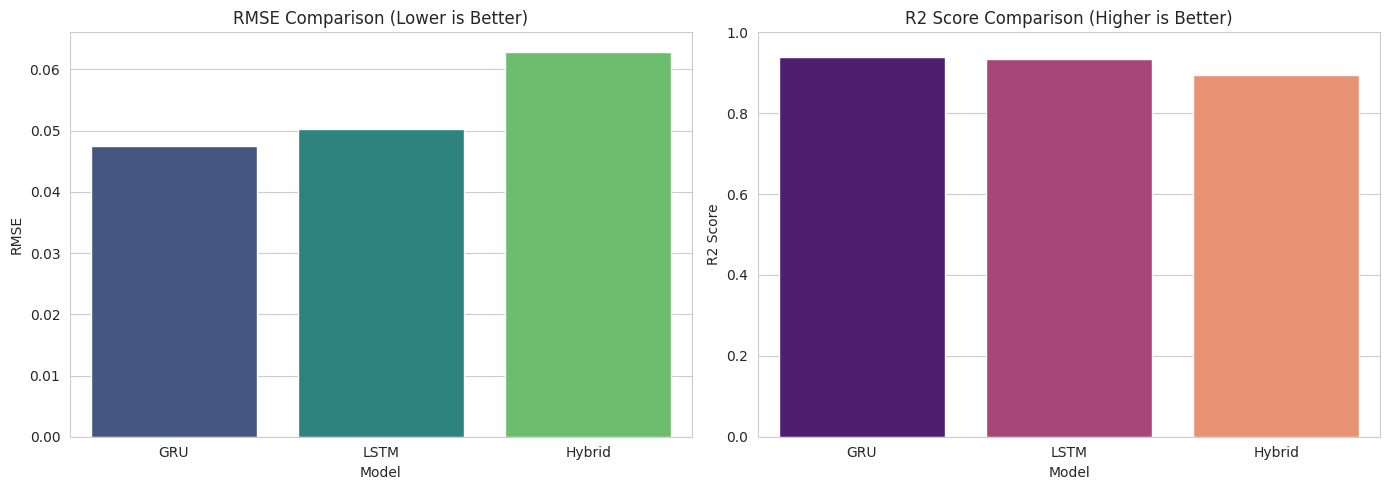

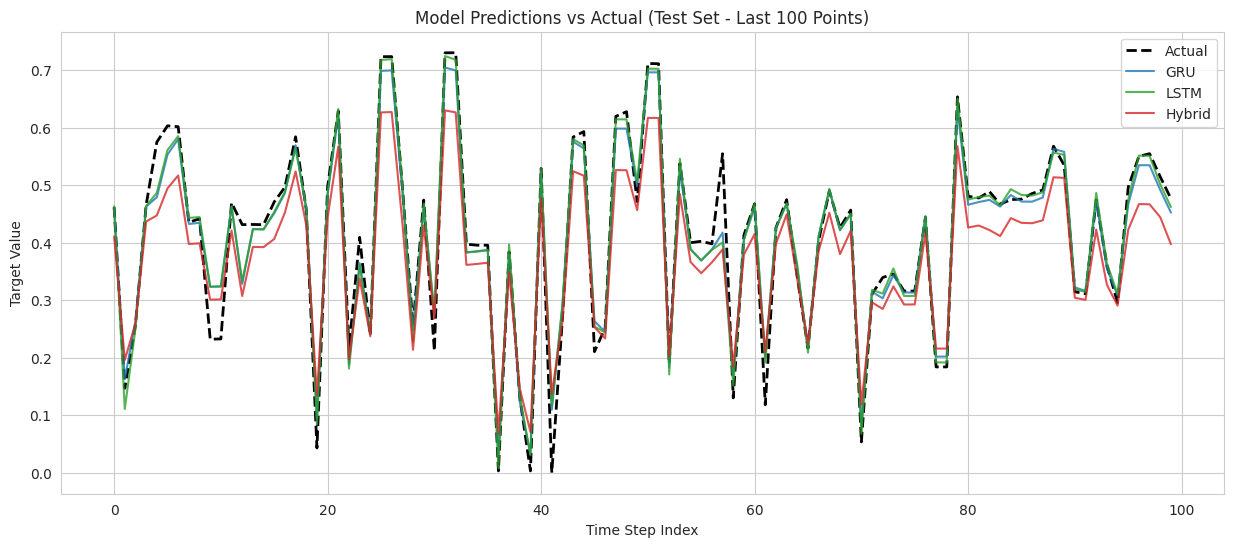

In [71]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# ==========================================
# 1. SETUP & MODEL LOADING
# ==========================================
model_files = {
    'GRU': 'GRU_Best.keras',
    'LSTM': 'LSTM_best.keras',
    'Hybrid': 'HYBRID_model.keras'
}

results = []
predictions = {}

print(f"Starting Model Comparison on {len(Y_test)} test samples...\n")

# ==========================================
# 2. PREDICTION LOOP
# ==========================================
for model_name, filename in model_files.items():
    # Load the trained model
    model = tf.keras.models.load_model(filename)

    # Use test_inputs (which contains [X_dyn_test, X_stat_test])
    # to match your model's multi-input signature
    pred = model.predict(test_inputs, verbose=0)

    # Ensure shape matches Y_test
    pred = pred.squeeze()

    # Store predictions for plotting
    predictions[model_name] = pred

    # Calculate Metrics against Y_test
    mae = mean_absolute_error(Y_test, pred)
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    r2 = r2_score(Y_test, pred)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# ==========================================
# 3. OUTPUT TABLE
# ==========================================
results_df = pd.DataFrame(results)

# ==========================================
# 4. VISUALIZATION
# ==========================================
sns.set_style("whitegrid")

# Plot A: Metrics Comparison Bar Chart
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='RMSE', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('RMSE Comparison (Lower is Better)')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='magma', hue='Model', legend=False)
plt.title('R2 Score Comparison (Higher is Better)')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Plot B: Prediction Overlay (Zoomed in on last 100 points)
plt.figure(figsize=(15, 6))

subset = 100
# Use Y_test for the actual values
plt.plot(Y_test[-subset:], label='Actual', color='black', linewidth=2, linestyle='--')

colors = {'GRU': '#1f77b4', 'LSTM': '#2ca02c', 'Hybrid': '#d62728'}

for model_name, pred_values in predictions.items():
    plt.plot(pred_values[-subset:], label=model_name, color=colors.get(model_name), alpha=0.8)

plt.title('Model Predictions vs Actual (Test Set - Last 100 Points)')
plt.xlabel('Time Step Index')
plt.ylabel('Target Value')
plt.legend()
plt.show()